# Playground Series S6E4 - Compact Ensemble and Thresholds

This notebook is the viewer-facing experiment page for the next modeling step after CatBoost tuning. It tests whether a compact probability ensemble and conservative `High`-class threshold adjustments can improve validation quality without replacing the stable CatBoost solution with a broad parameter search.

Technical focus:

- stratified cross-validation for imbalanced multiclass classification;
- out-of-fold probability generation;
- CatBoost and histogram gradient boosting model diversity;
- weighted probability blending;
- class-specific threshold testing for rare `High` irrigation need;
- Kaggle-ready final `submission.csv` generation.

Current best validation candidate from the latest run: CatBoost baseline `0.70` + histogram gradient boosting `0.30`, with a `P(High) >= 0.45` override.

## 1. Setup

Load the Kaggle modeling stack and define experiment controls. Defaults are Kaggle-safe but still run full stratified cross-validation.

In [1]:
from pathlib import Path
from IPython.display import display

import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier, Pool
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 140)
pd.set_option("display.float_format", "{:,.5f}".format)

sns.set_theme(style="whitegrid", context="notebook")
VIRIDIS_CMAP = "viridis"
RANDOM_STATE = 42
N_SPLITS = 3
RUN_CV = True
MAKE_SUBMISSION = True
WORKING_DIR = Path("/kaggle/working")

## 2. Data Loading

Find the competition files under `/kaggle/input`, then infer the ID and target columns from `sample_submission.csv`.

In [2]:
INPUT_ROOT = Path("/kaggle/input")

if not INPUT_ROOT.exists():
    raise RuntimeError(
        "This notebook is intended to run on Kaggle, where /kaggle/input is available."
    )


def find_file(filename: str) -> Path:
    """Return the first Kaggle input file matching the requested name.

    Args:
        filename: File name to search for below `/kaggle/input`.

    Returns:
        Path to the selected input file.
    """
    matches = sorted(INPUT_ROOT.rglob(filename))
    if not matches:
        raise FileNotFoundError(
            f"Could not find {filename} under {INPUT_ROOT}. "
            "Attach the competition data to this notebook."
        )
    if len(matches) > 1:
        print(f"Found multiple {filename} files. Using: {matches[0]}")
    return matches[0]


train = pd.read_csv(find_file("train.csv"))
test = pd.read_csv(find_file("test.csv"))
sample_submission = pd.read_csv(find_file("sample_submission.csv"))

target_col = sample_submission.columns[-1]
id_col = sample_submission.columns[0]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(train[target_col])
class_names = label_encoder.classes_.tolist()
high_class_idx = class_names.index("High") if "High" in class_names else None
medium_class_idx = class_names.index("Medium") if "Medium" in class_names else None

print(f"train shape: {train.shape}")
print(f"test shape: {test.shape}")
print("classes:", class_names)
display(train[target_col].value_counts(normalize=True).mul(100).rename("target_pct"))

train shape: (630000, 21)
test shape: (270000, 20)
classes: ['High', 'Low', 'Medium']


Irrigation_Need
Low      58.71698
Medium   37.94825
High      3.33476
Name: target_pct, dtype: float64

## 3. Feature Preparation

Reuse the EDA-driven interaction features that remained strongest during CatBoost tuning. Keep the feature space compact so ensemble changes can be attributed to model diversity rather than feature churn.

In [3]:
base_feature_cols = [c for c in train.columns if c not in {id_col, target_col}]

INTERACTION_PAIRS = [
    ("Crop_Growth_Stage", "Mulching_Used"),
    ("Crop_Growth_Stage", "Water_Source"),
    ("Crop_Growth_Stage", "Irrigation_Type"),
]


def add_interaction_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add compact EDA-driven categorical interaction features.

    Args:
        df: Input train or test frame.

    Returns:
        Copy of the input frame with interaction columns added.
    """
    out = df.copy()
    for left, right in INTERACTION_PAIRS:
        if left in out.columns and right in out.columns:
            out[f"{left}__x__{right}"] = (
                out[left].astype(str) + "__" + out[right].astype(str)
            )
    return out


train_fe = add_interaction_features(train)
test_fe = add_interaction_features(test)

feature_cols = [c for c in train_fe.columns if c not in {id_col, target_col}]
numeric_cols = train_fe[feature_cols].select_dtypes(include=np.number).columns.tolist()
categorical_cols = [c for c in feature_cols if c not in numeric_cols]

X = train_fe[feature_cols]
X_test = test_fe[feature_cols]

print("Base feature count:", len(base_feature_cols))
print("Ensemble feature count:", len(feature_cols))
print("Interaction columns:", [c for c in feature_cols if "__x__" in c])

Base feature count: 19
Ensemble feature count: 22
Interaction columns: ['Crop_Growth_Stage__x__Mulching_Used', 'Crop_Growth_Stage__x__Water_Source', 'Crop_Growth_Stage__x__Irrigation_Type']


## 4. Evaluation Utilities

Use one metric function for individual models, ensembles, and threshold experiments. Macro F1 remains the primary selection metric.

In [4]:
def evaluate_predictions(
    y_true: np.ndarray, pred: np.ndarray, proba: np.ndarray
) -> dict[str, float]:
    """Calculate multiclass validation metrics and per-class scores."""
    row = {
        "accuracy": accuracy_score(y_true, pred),
        "macro_f1": f1_score(y_true, pred, average="macro"),
        "weighted_f1": f1_score(y_true, pred, average="weighted"),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "log_loss": log_loss(y_true, proba, labels=np.arange(len(class_names))),
    }
    report = classification_report(
        y_true,
        pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
    for label in class_names:
        row[f"{label}_precision"] = report[label]["precision"]
        row[f"{label}_recall"] = report[label]["recall"]
        row[f"{label}_f1"] = report[label]["f1-score"]
    return row


def plot_confusion(y_true: np.ndarray, pred: np.ndarray, title: str) -> None:
    """Plot count and row-normalized confusion matrices."""
    cm = confusion_matrix(y_true, pred, labels=np.arange(len(class_names)))
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=VIRIDIS_CMAP,
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[0],
    )
    axes[0].set_title(f"{title} - Counts")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".3f",
        cmap=VIRIDIS_CMAP,
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[1],
    )
    axes[1].set_title(f"{title} - Row Normalized")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Actual")
    plt.tight_layout()
    plt.show()

## 5. Model Definitions

Compare the tuned CatBoost baseline against a deeper CatBoost variant and histogram gradient boosting. Histogram gradient boosting is included because the baseline notebook showed it was close on macro F1 and better on log loss.

In [5]:
def get_categorical_columns(df: pd.DataFrame, cols: list[str]) -> list[str]:
    """Return feature names that CatBoost should treat as categorical."""
    return [
        c
        for c in cols
        if df[c].dtype == "object" or str(df[c].dtype).startswith("category")
    ]


def make_pool(
    df: pd.DataFrame, cols: list[str], target: np.ndarray | None = None
) -> Pool:
    """Build a CatBoost Pool with inferred categorical feature indices."""
    cat_cols = get_categorical_columns(df, cols)
    cat_indices = [cols.index(c) for c in cat_cols]
    return Pool(df[cols], label=target, cat_features=cat_indices)


def make_hgb_pipeline() -> Pipeline:
    """Build the histogram gradient boosting preprocessing pipeline."""
    numeric_transformer = Pipeline(
        steps=[("imputer", SimpleImputer(strategy="median"))]
    )
    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "encoder",
                OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1,
                ),
            ),
        ]
    )
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols),
        ]
    )
    model = HistGradientBoostingClassifier(
        max_iter=500,
        learning_rate=0.06,
        max_leaf_nodes=31,
        l2_regularization=0.01,
        random_state=RANDOM_STATE,
    )
    return Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])


BASE_CATBOOST_PARAMS = {
    "loss_function": "MultiClass",
    "eval_metric": "TotalF1",
    "random_seed": RANDOM_STATE,
    "verbose": False,
    "allow_writing_files": False,
    "thread_count": -1,
}

MODEL_SPECS = {
    "catboost_baseline": {
        "kind": "catboost",
        "params": {
            **BASE_CATBOOST_PARAMS,
            "iterations": 600,
            "learning_rate": 0.06,
            "depth": 7,
            "l2_leaf_reg": 3.0,
        },
    },
    "catboost_deeper": {
        "kind": "catboost",
        "params": {
            **BASE_CATBOOST_PARAMS,
            "iterations": 800,
            "learning_rate": 0.045,
            "depth": 8,
            "l2_leaf_reg": 4.0,
            "random_strength": 1.0,
        },
    },
    "hist_gradient_boosting": {
        "kind": "hgb",
        "params": {},
    },
}

display(
    pd.DataFrame(
        [
            {
                "model": name,
                "kind": spec["kind"],
                **{
                    k: v
                    for k, v in spec.get("params", {}).items()
                    if k
                    not in {
                        "loss_function",
                        "eval_metric",
                        "verbose",
                        "allow_writing_files",
                        "thread_count",
                    }
                },
            }
            for name, spec in MODEL_SPECS.items()
        ]
    )
)

,model,kind,random_seed,iterations,learning_rate,depth,l2_leaf_reg,random_strength
0,catboost_baseline,catboost,42.00000,600.00000,0.06000,7.00000,3.00000,NaN
1,catboost_deeper,catboost,42.00000,800.00000,0.04500,8.00000,4.00000,1.00000
2,hist_gradient_boosting,hgb,NaN,NaN,NaN,NaN,NaN,NaN


## 6. Out-of-Fold Model Probabilities

Train each base model with stratified folds and save out-of-fold probabilities. These probabilities are the evidence base for ensemble weights and threshold tests.

In [6]:
def fit_predict_fold(
    model_name: str,
    spec: dict,
    train_idx: np.ndarray,
    valid_idx: np.ndarray,
) -> np.ndarray:
    """Fit one fold and return validation probabilities."""
    if spec["kind"] == "catboost":
        train_pool = make_pool(X.iloc[train_idx], feature_cols, y[train_idx])
        valid_pool = make_pool(X.iloc[valid_idx], feature_cols, y[valid_idx])
        model = CatBoostClassifier(**spec["params"])
        model.fit(train_pool, eval_set=valid_pool, use_best_model=True)
        proba = model.predict_proba(valid_pool)
        del train_pool, valid_pool, model
        gc.collect()
        return proba

    if spec["kind"] == "hgb":
        model = make_hgb_pipeline()
        model.fit(X.iloc[train_idx], y[train_idx])
        proba = model.predict_proba(X.iloc[valid_idx])
        del model
        gc.collect()
        return proba

    raise ValueError(f"Unsupported model kind for {model_name}: {spec['kind']}")


model_oof_probabilities = {}
model_cv_rows = []

if RUN_CV:
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    for model_name, spec in MODEL_SPECS.items():
        print(f"Running CV for {model_name}")
        oof_proba = np.zeros((len(X), len(class_names)), dtype=float)
        for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):
            proba = fit_predict_fold(model_name, spec, train_idx, valid_idx)
            pred = proba.argmax(axis=1)
            oof_proba[valid_idx] = proba
            row = evaluate_predictions(y[valid_idx], pred, proba)
            row.update({"model": model_name, "fold": fold})
            model_cv_rows.append(row)
            high_recall = row.get("High_recall", np.nan)
            print(
                f"  fold {fold}: macro_f1={row['macro_f1']:.5f}, "
                f"log_loss={row['log_loss']:.5f}, "
                f"High_recall={high_recall:.5f}"
            )
        model_oof_probabilities[model_name] = oof_proba

    model_cv_results = pd.DataFrame(model_cv_rows)
    display(model_cv_results)
    model_cv_summary = (
        model_cv_results.groupby("model")
        .agg(["mean", "std"])
        .sort_values(("macro_f1", "mean"), ascending=False)
    )
    display(model_cv_summary)
else:
    model_cv_results = pd.DataFrame()
    model_cv_summary = pd.DataFrame()
    print("Cross-validation disabled. Set RUN_CV = True to test ensembles.")

Running CV for catboost_baseline
  fold 1: macro_f1=0.97032, log_loss=0.06187, High_recall=0.91189
  fold 2: macro_f1=0.97000, log_loss=0.06086, High_recall=0.91475
  fold 3: macro_f1=0.96949, log_loss=0.05991, High_recall=0.91218
Running CV for catboost_deeper
  fold 1: macro_f1=0.97061, log_loss=0.06003, High_recall=0.91304
  fold 2: macro_f1=0.96968, log_loss=0.06076, High_recall=0.91347
  fold 3: macro_f1=0.96938, log_loss=0.05969, High_recall=0.91161
Running CV for hist_gradient_boosting
  fold 1: macro_f1=0.96952, log_loss=0.05971, High_recall=0.91618
  fold 2: macro_f1=0.97007, log_loss=0.05910, High_recall=0.91704
  fold 3: macro_f1=0.96951, log_loss=0.05822, High_recall=0.91632


,accuracy,macro_f1,weighted_f1,balanced_accuracy,log_loss,High_precision,High_recall,High_f1,Low_precision,Low_recall,Low_f1,Medium_precision,Medium_recall,Medium_f1,model,fold
0,0.98507,0.97032,0.98500,0.96095,0.06187,0.97007,0.91189,0.94009,0.98600,0.99530,0.99063,0.98485,0.97566,0.98023,catboost_baseline,1
1,0.98464,0.97000,0.98458,0.96149,0.06086,0.96680,0.91475,0.94005,0.98552,0.99509,0.99028,0.98476,0.97461,0.97966,catboost_baseline,2
2,0.98452,0.96949,0.98445,0.96071,0.05991,0.96685,0.91218,0.93872,0.98606,0.99446,0.99024,0.98358,0.97549,0.97952,catboost_baseline,3
3,0.98509,0.97061,0.98502,0.96132,0.06003,0.97070,0.91304,0.94099,0.98597,0.99526,0.99060,0.98489,0.97567,0.98026,catboost_deeper,1
4,0.98456,0.96968,0.98449,0.96103,0.06076,0.96646,0.91347,0.93922,0.98549,0.99508,0.99026,0.98462,0.97454,0.97955,catboost_deeper,2
5,0.98453,0.96938,0.98446,0.96053,0.05969,0.96669,0.91161,0.93834,0.98604,0.99453,0.99027,0.98364,0.97546,0.97953,catboost_deeper,3
6,0.98396,0.96952,0.98390,0.96149,0.05971,0.96525,0.91618,0.94007,0.98526,0.99419,0.98971,0.98349,0.97409,0.97877,hist_gradient_boosting,1
7,0.98459,0.97007,0.98452,0.96215,0.05910,0.96499,0.91704,0.94040,0.98548,0.99501,0.99022,0.98483,0.97439,0.97958,hist_gradient_boosting,2
8,0.98419,0.96951,0.98413,0.96173,0.05822,0.96395,0.91632,0.93953,0.98570,0.99420,0.98993,0.98353,0.97466,0.97908,hist_gradient_boosting,3


accuracy         macro_f1         weighted_f1          \
                           mean     std     mean     std        mean     std   
model                                                                          
catboost_baseline       0.98474 0.00029  0.96994 0.00041     0.98468 0.00029   
catboost_deeper         0.98473 0.00031  0.96989 0.00064     0.98466 0.00031   
hist_gradient_boosting  0.98425 0.00032  0.96970 0.00032     0.98418 0.00032   

                       balanced_accuracy         log_loss          \
                                    mean     std     mean     std   
model                                                               
catboost_baseline                0.96105 0.00040  0.06088 0.00098   
catboost_deeper                  0.96096 0.00040  0.06016 0.00055   
hist_gradient_boosting           0.96179 0.00033  0.05901 0.00075   

                       High_precision         High_recall         High_f1  \
                                 mean     std        mean     std    mean   
model                                                                       
catboost_baseline             0.96791 0.00188     0.91294 0.00157 0.93962   
catboost_deeper               0.96795 0.00239     0.91270 0.00097 0.93951   
hist_gradient_boosting        0.96473 0.00069     0.91651 0.00046 0.94000   

                               Low_precision         Low_recall          \
                           std          mean     std       mean     std   
model                                                                     
catboost_baseline      0.00078       0.98586 0.00029    0.99495 0.00044   
catboost_deeper        0.00135       0.98583 0.00030    0.99496 0.00038   
hist_gradient_boosting 0.00044       0.98548 0.00022    0.99447 0.00047   

                        Low_f1         Medium_precision         Medium_recall  \
                          mean     std             mean     std          mean   
model                                                                           
catboost_baseline      0.99038 0.00021          0.98440 0.00071       0.97525   
catboost_deeper        0.99037 0.00019          0.98438 0.00066       0.97522   
hist_gradient_boosting 0.98995 0.00026          0.98395 0.00076       0.97438   

                               Medium_f1            fold          
                           std      mean     std    mean     std  
model                                                             
catboost_baseline      0.00056   0.97980 0.00038 2.00000 1.00000  
catboost_deeper        0.00060   0.97978 0.00041 2.00000 1.00000  
hist_gradient_boosting 0.00029   0.97914 0.00041 2.00000 1.00000

## 7. Weighted Probability Ensembles

Average model probabilities with a small, interpretable weight grid. Select by macro F1 first, then use log loss and `High` recall as tie-breakers.

Viewer note: the goal is not to find a perfect weight grid. The goal is to test whether HGB contributes complementary probability signal beyond the stable CatBoost baseline.

In [7]:
ENSEMBLE_WEIGHT_GRID = [
    {"catboost_baseline": 1.00},
    {"catboost_baseline": 0.80, "hist_gradient_boosting": 0.20},
    {"catboost_baseline": 0.70, "hist_gradient_boosting": 0.30},
    {"catboost_baseline": 0.75, "catboost_deeper": 0.25},
    {
        "catboost_baseline": 0.60,
        "hist_gradient_boosting": 0.20,
        "catboost_deeper": 0.20,
    },
]


def normalize_weights(
    weights: dict[str, float], available_names: set[str] | None = None
) -> dict[str, float]:
    """Normalize positive model weights to sum to one."""
    if available_names is None:
        available_names = set(weights)
    available = {k: v for k, v in weights.items() if k in available_names}
    total = sum(available.values())
    if total <= 0:
        raise ValueError(f"No available models for weights: {weights}")
    return {k: v / total for k, v in available.items()}


def blend_probabilities(
    probability_map: dict[str, np.ndarray], weights: dict[str, float]
) -> np.ndarray:
    """Return weighted average probabilities for the selected models."""
    normalized = normalize_weights(weights, set(probability_map))
    blended = np.zeros_like(next(iter(probability_map.values())))
    for model_name, weight in normalized.items():
        blended += probability_map[model_name] * weight
    return blended


ensemble_rows = []

if RUN_CV and model_oof_probabilities:
    for weights in ENSEMBLE_WEIGHT_GRID:
        normalized_weights = normalize_weights(weights)
        proba = blend_probabilities(model_oof_probabilities, normalized_weights)
        pred = proba.argmax(axis=1)
        row = evaluate_predictions(y, pred, proba)
        row.update(
            {
                "ensemble": " + ".join(
                    f"{name}:{weight:.2f}"
                    for name, weight in normalized_weights.items()
                ),
                "weights": normalized_weights,
            }
        )
        ensemble_rows.append(row)

    ensemble_results = pd.DataFrame(ensemble_rows).sort_values(
        ["macro_f1", "log_loss"], ascending=[False, True]
    )
    display(ensemble_results)
else:
    ensemble_results = pd.DataFrame()
    print("No OOF probabilities available for ensemble testing.")

,accuracy,macro_f1,weighted_f1,balanced_accuracy,log_loss,High_precision,High_recall,High_f1,Low_precision,Low_recall,Low_f1,Medium_precision,Medium_recall,Medium_f1,ensemble,weights
2,0.98485,0.97022,0.98479,0.96141,0.05934,0.96828,0.91385,0.94027,0.98590,0.99503,0.99044,0.98460,0.97534,0.97995,catboost_baseline:0.70 + hist_gradient_boostin...,"{'catboost_baseline': 0.7, 'hist_gradient_boos..."
1,0.98484,0.97018,0.98477,0.96131,0.05972,0.96837,0.91356,0.94017,0.98588,0.99504,0.99044,0.98458,0.97532,0.97993,catboost_baseline:0.80 + hist_gradient_boostin...,"{'catboost_baseline': 0.8, 'hist_gradient_boos..."
4,0.98483,0.97015,0.98476,0.96128,0.05956,0.96827,0.91351,0.94009,0.98588,0.99503,0.99043,0.98456,0.97531,0.97992,catboost_baseline:0.60 + hist_gradient_boostin...,"{'catboost_baseline': 0.6, 'hist_gradient_boos..."
0,0.98474,0.96994,0.98468,0.96105,0.06088,0.96790,0.91294,0.93962,0.98586,0.99495,0.99038,0.98440,0.97525,0.97980,catboost_baseline:1.00,{'catboost_baseline': 1.0}
3,0.98472,0.96987,0.98466,0.96093,0.06064,0.96794,0.91261,0.93946,0.98585,0.99494,0.99037,0.98435,0.97525,0.97978,catboost_baseline:0.75 + catboost_deeper:0.25,"{'catboost_baseline': 0.75, 'catboost_deeper':..."


## 8. Conservative High-Class Thresholds

Use the best ensemble probabilities and test small decision adjustments for `High`. Keep the default argmax unless the out-of-fold macro F1 improves.

Viewer note: this is intentionally more conservative than class weighting. The earlier weighted CatBoost experiment raised `High` recall but hurt macro F1 and log loss, so this section tests smaller decision-level nudges.

,accuracy,macro_f1,weighted_f1,balanced_accuracy,log_loss,High_precision,High_recall,High_f1,Low_precision,Low_recall,Low_f1,Medium_precision,Medium_recall,Medium_f1,rule,high_threshold,high_to_medium_ratio
6,0.98486,0.97032,0.98480,0.96228,0.05934,0.96570,0.91670,0.94056,0.98590,0.99503,0.99044,0.98485,0.97511,0.97996,P(High)>=0.45,0.45000,NaN
11,0.98486,0.97032,0.98480,0.96238,0.05934,0.96533,0.91704,0.94056,0.98590,0.99503,0.99044,0.98488,0.97509,0.97996,P(High)/P(Medium)>=0.80,NaN,0.80000
12,0.98485,0.97025,0.98479,0.96189,0.05934,0.96672,0.91542,0.94037,0.98590,0.99503,0.99044,0.98474,0.97521,0.97995,P(High)/P(Medium)>=0.90,NaN,0.90000
0,0.98485,0.97022,0.98479,0.96141,0.05934,0.96828,0.91385,0.94027,0.98590,0.99503,0.99044,0.98460,0.97534,0.97995,argmax,NaN,NaN
7,0.98485,0.97022,0.98479,0.96141,0.05934,0.96828,0.91385,0.94027,0.98590,0.99503,0.99044,0.98460,0.97534,0.97995,P(High)>=0.50,0.50000,NaN
5,0.98483,0.97021,0.98477,0.96305,0.05934,0.96219,0.91932,0.94027,0.98590,0.99503,0.99044,0.98507,0.97480,0.97991,P(High)>=0.40,0.40000,NaN
10,0.98483,0.97019,0.98477,0.96285,0.05934,0.96283,0.91865,0.94023,0.98590,0.99503,0.99044,0.98501,0.97487,0.97992,P(High)/P(Medium)>=0.70,NaN,0.70000
9,0.98480,0.97010,0.98475,0.96336,0.05934,0.96037,0.92042,0.93997,0.98589,0.99502,0.99044,0.98516,0.97465,0.97988,P(High)/P(Medium)>=0.60,NaN,0.60000
4,0.98478,0.97001,0.98473,0.96376,0.05934,0.95843,0.92180,0.93975,0.98590,0.99503,0.99044,0.98528,0.97446,0.97984,P(High)>=0.35,0.35000,NaN
8,0.98475,0.96985,0.98470,0.96392,0.05934,0.95685,0.92241,0.93931,0.98589,0.99502,0.99044,0.98533,0.97434,0.97981,P(High)/P(Medium)>=0.50,NaN,0.50000


Selected ensemble weights: {'catboost_baseline': 0.7, 'hist_gradient_boosting': 0.3}
Selected High rule: P(High)>=0.45
              precision    recall  f1-score   support

        High       0.97      0.92      0.94     21009
         Low       0.99      1.00      0.99    369917
      Medium       0.98      0.98      0.98    239074

    accuracy                           0.98    630000
   macro avg       0.98      0.96      0.97    630000
weighted avg       0.98      0.98      0.98    630000



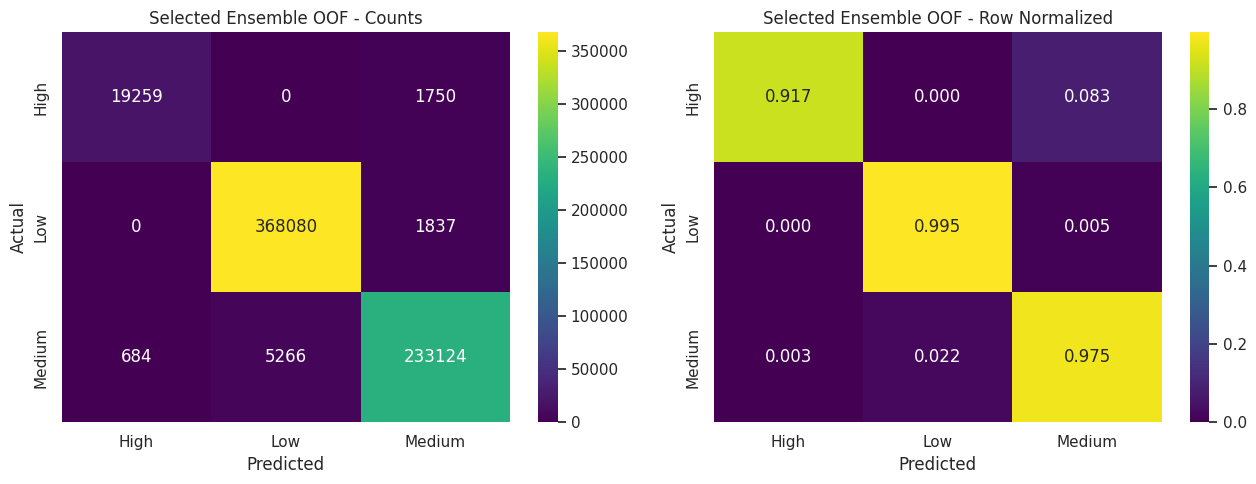

In [8]:
HIGH_THRESHOLDS = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
HIGH_TO_MEDIUM_RATIOS = [0.50, 0.60, 0.70, 0.80, 0.90]


def apply_high_rule(
    proba: np.ndarray,
    high_threshold: float | None = None,
    high_to_medium_ratio: float | None = None,
) -> np.ndarray:
    """Apply a conservative High override to argmax predictions."""
    pred = proba.argmax(axis=1)
    if high_class_idx is None:
        return pred

    high_mask = np.zeros(len(proba), dtype=bool)
    if high_threshold is not None:
        high_mask |= proba[:, high_class_idx] >= high_threshold
    if high_to_medium_ratio is not None and medium_class_idx is not None:
        ratio = proba[:, high_class_idx] / np.maximum(proba[:, medium_class_idx], 1e-12)
        high_mask |= ratio >= high_to_medium_ratio
    pred[high_mask] = high_class_idx
    return pred


threshold_rows = []

if RUN_CV and not ensemble_results.empty:
    best_ensemble_row = ensemble_results.iloc[0]
    selected_weights = best_ensemble_row["weights"]
    selected_oof_proba = blend_probabilities(
        model_oof_probabilities,
        selected_weights,
    )

    default_pred = selected_oof_proba.argmax(axis=1)
    default_row = evaluate_predictions(y, default_pred, selected_oof_proba)
    default_row.update(
        {
            "rule": "argmax",
            "high_threshold": np.nan,
            "high_to_medium_ratio": np.nan,
        }
    )
    threshold_rows.append(default_row)

    for threshold in HIGH_THRESHOLDS:
        pred = apply_high_rule(selected_oof_proba, high_threshold=threshold)
        row = evaluate_predictions(y, pred, selected_oof_proba)
        row.update(
            {
                "rule": f"P(High)>={threshold:.2f}",
                "high_threshold": threshold,
                "high_to_medium_ratio": np.nan,
            }
        )
        threshold_rows.append(row)

    for ratio in HIGH_TO_MEDIUM_RATIOS:
        pred = apply_high_rule(selected_oof_proba, high_to_medium_ratio=ratio)
        row = evaluate_predictions(y, pred, selected_oof_proba)
        row.update(
            {
                "rule": f"P(High)/P(Medium)>={ratio:.2f}",
                "high_threshold": np.nan,
                "high_to_medium_ratio": ratio,
            }
        )
        threshold_rows.append(row)

    threshold_results = pd.DataFrame(threshold_rows).sort_values(
        ["macro_f1", "log_loss"], ascending=[False, True]
    )
    display(threshold_results)

    selected_threshold_row = threshold_results.iloc[0]
    selected_high_threshold = selected_threshold_row["high_threshold"]
    selected_high_to_medium_ratio = selected_threshold_row["high_to_medium_ratio"]
    selected_oof_pred = apply_high_rule(
        selected_oof_proba,
        high_threshold=(
            None if pd.isna(selected_high_threshold) else selected_high_threshold
        ),
        high_to_medium_ratio=(
            None
            if pd.isna(selected_high_to_medium_ratio)
            else selected_high_to_medium_ratio
        ),
    )
    print("Selected ensemble weights:", selected_weights)
    print("Selected High rule:", selected_threshold_row["rule"])
    print(classification_report(y, selected_oof_pred, target_names=class_names))
    plot_confusion(y, selected_oof_pred, "Selected Ensemble OOF")
else:
    threshold_results = pd.DataFrame()
    selected_weights = {"catboost_baseline": 1.0}
    selected_high_threshold = np.nan
    selected_high_to_medium_ratio = np.nan
    print("Using default CatBoost weights because CV results are unavailable.")

## 9. Final Training and Submission

Train the selected model set on all training rows, blend test probabilities, apply the selected `High` rule, and write `/kaggle/working/submission.csv`.

In [9]:
def fit_full_model(model_name: str, spec: dict):
    """Fit one selected model on all training rows."""
    if spec["kind"] == "catboost":
        model = CatBoostClassifier(**spec["params"])
        model.fit(make_pool(train_fe, feature_cols, y))
        return model

    if spec["kind"] == "hgb":
        model = make_hgb_pipeline()
        model.fit(X, y)
        return model

    raise ValueError(f"Unsupported model kind for {model_name}: {spec['kind']}")


def predict_full_model(model_name: str, spec: dict, model) -> np.ndarray:
    """Predict test probabilities for one fitted full-data model."""
    if spec["kind"] == "catboost":
        return model.predict_proba(make_pool(test_fe, feature_cols))

    if spec["kind"] == "hgb":
        return model.predict_proba(X_test)

    raise ValueError(f"Unsupported model kind for {model_name}: {spec['kind']}")


if MAKE_SUBMISSION:
    selected_weights = normalize_weights(selected_weights)
    test_probability_map = {}

    for model_name in selected_weights:
        print(f"Training final {model_name}")
        spec = MODEL_SPECS[model_name]
        model = fit_full_model(model_name, spec)
        test_probability_map[model_name] = predict_full_model(model_name, spec, model)
        del model
        gc.collect()

    test_proba = blend_probabilities(test_probability_map, selected_weights)
    test_pred = apply_high_rule(
        test_proba,
        high_threshold=(
            None if pd.isna(selected_high_threshold) else selected_high_threshold
        ),
        high_to_medium_ratio=(
            None
            if pd.isna(selected_high_to_medium_ratio)
            else selected_high_to_medium_ratio
        ),
    )
    test_labels = label_encoder.inverse_transform(test_pred)

    submission = sample_submission.copy()
    submission[target_col] = test_labels
    output_path = WORKING_DIR / "submission.csv"
    submission.to_csv(output_path, index=False)

    display(submission.head())
    display(
        submission[target_col]
        .value_counts(normalize=True)
        .mul(100)
        .rename("prediction_pct")
        .to_frame()
    )
    print("Selected weights:", selected_weights)
    print("Selected High threshold:", selected_high_threshold)
    print("Selected High/Medium ratio:", selected_high_to_medium_ratio)
    print(f"Wrote {output_path}")
else:
    print("Submission creation disabled.")

Training final catboost_baseline
Training final hist_gradient_boosting


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low


,prediction_pct
Irrigation_Need,
Low,59.22815
Medium,37.57481
High,3.19704


Selected weights: {'catboost_baseline': 0.7, 'hist_gradient_boosting': 0.3}
Selected High threshold: 0.45
Selected High/Medium ratio: nan
Wrote /kaggle/working/submission.csv


## 10. Experiment Notes

Latest run summary:

- Best individual model by CV macro F1 remained CatBoost baseline at `0.96994`.
- HGB had slightly lower macro F1 at `0.96970`, but better mean log loss at `0.05901`.
- Best probability blend was CatBoost baseline `0.70` + HGB `0.30`, reaching `0.97022` CV macro F1.
- Best decision rule was `P(High) >= 0.45`, reaching `0.97032` CV macro F1 and `0.91670` `High` recall.
- Final candidate prediction mix was `Low 59.23%`, `Medium 37.57%`, and `High 3.20%`.

Decision:

- Submit this candidate once and compare with the current `0.96094` public score.
- Promote the ensemble only if the leaderboard confirms the cross-validation gain.
- Keep the CatBoost tuning submission as the stable fallback if the ensemble does not generalize.

Next evidence to record after submission:

- public leaderboard score;
- whether the ensemble beats the stable CatBoost submission;
- any change in prediction mix if the threshold grid is narrowed.